In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style('darkgrid')
plt.rcParams['font.size'] = 14
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.facecolor'] = '#00000000'

In [2]:
df = pd.read_csv('../data/Titanic-Dataset.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [4]:
df.select_dtypes('number').corr()['Survived'].sort_values(ascending = False)

Survived       1.000000
Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.077221
Pclass        -0.338481
Name: Survived, dtype: float64

/var/folders/m5/wc3t95214dv1ztzfcqj6nd_00000gn/T/ipykernel_7930/1703835120.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df, x = 'Survived', ax = axes[0, 0], palette = 'Set1')


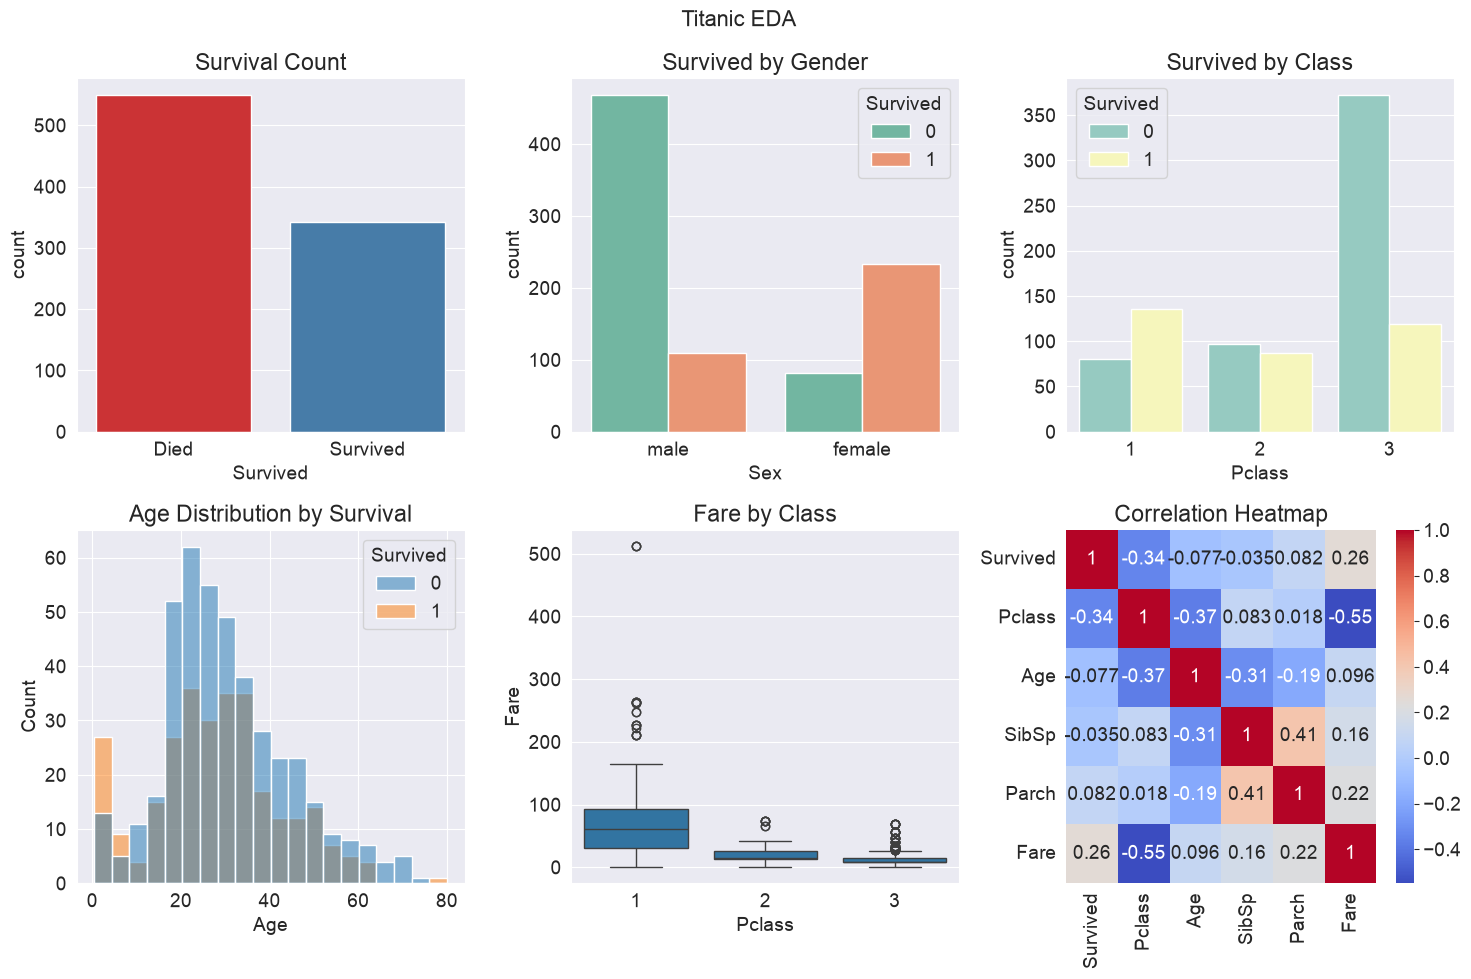

In [5]:
fig, axes = plt.subplots(2, 3, figsize = (15, 10))
fig.suptitle('Titanic EDA', fontsize = 16)

sns.countplot(df, x = 'Survived', ax = axes[0, 0], palette = 'Set1')
axes[0, 0].set_title('Survival Count')
axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_xticklabels(['Died', 'Survived'])

sns.countplot(df, x = 'Sex', hue = 'Survived', ax = axes[0, 1], palette = 'Set2')
axes[0, 1].set_title('Survived by Gender')

sns.countplot(df, x = 'Pclass', hue = 'Survived', ax = axes[0, 2], palette = 'Set3')
axes[0, 2].set_title('Survived by Class')

sns.histplot(df, x = 'Age', hue = 'Survived', ax = axes[1, 0], bins = 20)
axes[1, 0].set_title('Age Distribution by Survival')

sns.boxplot(df, x = 'Pclass', y = 'Fare', ax = axes[1, 1])
axes[1, 1].set_title('Fare by Class')

numeric_df = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]
sns.heatmap(numeric_df.corr(), annot = True, cmap = 'coolwarm', ax = axes[1, 2])
axes[1, 2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

In [6]:
df['Title'] = df['Name'].str.split(',').str[1].str.split('.').str[0].str.strip()
df['Title'].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [7]:
df['Title'] = df['Title'].replace(['Dr', 'Rev', 'Col', 'Major', 'Mlle', 
                                    'Countess', 'Ms', 'Lady', 'Jonkheer', 
                                    'Don', 'Dona', 'Mme', 'Capt', 'Sir'], 'Other')

df['Title'].value_counts()

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100], labels=['Child', 'Teen', 'Adult', 'Middle', 'Senior'])

df['FarePerPerson'] = df['Fare'] / df['FamilySize']


df[['Name', 'Title', 'FamilySize', 'IsAlone', 'AgeGroup', 'FarePerPerson']].head(10)

,Name,Title,FamilySize,IsAlone,AgeGroup,FarePerPerson
0,"Braund, Mr. Owen Harris",Mr,2,0,Adult,3.62500
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,2,0,Middle,35.64165
2,"Heikkinen, Miss. Laina",Miss,1,1,Adult,7.92500
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,2,0,Adult,26.55000
4,"Allen, Mr. William Henry",Mr,1,1,Adult,8.05000
5,"Moran, Mr. James",Mr,1,1,NaN,8.45830
6,"McCarthy, Mr. Timothy J",Mr,1,1,Middle,51.86250
7,"Palsson, Master. Gosta Leonard",Master,5,0,Child,4.21500
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",Mrs,3,0,Adult,3.71110
9,"Nasser, Mrs. Nicholas (Adele Achem)",Mrs,2,0,Teen,15.03540


In [8]:
df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df = df.drop(['Cabin'], axis = 1)

In [9]:
df['Age'].isna().sum()

np.int64(0)

In [10]:
df['Embarked'].isna().sum()

np.int64(0)

In [11]:
input_cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize',
              'IsAlone', 'AgeGroup', 'FarePerPerson']

target_col = 'Survived'
df[input_cols].nunique()

Pclass             3
Sex                2
Age               88
SibSp              7
Parch              7
Fare             248
Embarked           3
Title              6
FamilySize         9
IsAlone            2
AgeGroup           5
FarePerPerson    289
dtype: int64

In [12]:
from sklearn.model_selection import train_test_split

train_val_df, test_df = train_test_split(df, test_size = 0.1, random_state = 42)

train_df, val_df = train_test_split(train_val_df, test_size = 0.1, random_state = 42)

print(f"Train size: {len(train_df)}")
print(f"Val size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

Train size: 720
Val size: 81
Test size: 90


In [13]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

test_inputs = test_df[input_cols].copy()
test_targets = test_df[target_col].copy()

In [14]:
from sklearn.impute import SimpleImputer

In [15]:
numeric_cols = train_inputs.select_dtypes(['number']).columns.tolist()
categorical_cols = train_inputs.select_dtypes(['object', 'category']).columns.tolist()

/var/folders/m5/wc3t95214dv1ztzfcqj6nd_00000gn/T/ipykernel_7930/2417480166.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train_inputs.select_dtypes(['object', 'category']).columns.tolist()


In [16]:
numeric_cols

['Pclass',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'FamilySize',
 'IsAlone',
 'FarePerPerson']

In [17]:
categorical_cols

['Sex', 'Embarked', 'Title', 'AgeGroup']

In [18]:
imputer = SimpleImputer(strategy = 'median').fit(train_inputs[numeric_cols])

In [19]:
train_inputs[numeric_cols] = imputer.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = imputer.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = imputer.transform(test_inputs[numeric_cols])

In [20]:
from sklearn.preprocessing import MinMaxScaler

In [21]:
scaler = MinMaxScaler().fit(train_inputs[numeric_cols])

In [22]:
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = scaler.transform(test_inputs[numeric_cols])

In [23]:
val_inputs[numeric_cols]

,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,FarePerPerson
216,1.0,0.334004,0.000,0.000000,0.015469,0.0,1.0,0.015469
32,1.0,0.346569,0.000,0.000000,0.015127,0.0,1.0,0.015127
109,1.0,0.346569,0.125,0.000000,0.047138,0.1,0.0,0.023569
262,0.0,0.648153,0.125,0.166667,0.155466,0.2,0.0,0.051822
643,1.0,0.346569,0.000,0.000000,0.110272,0.0,1.0,0.110272
...,...,...,...,...,...,...,...,...
881,1.0,0.409399,0.000,0.000000,0.015412,0.0,1.0,0.015412
364,1.0,0.346569,0.125,0.000000,0.030254,0.1,0.0,0.015127
373,0.0,0.271174,0.000,0.000000,0.264739,0.0,1.0,0.264739
129,1.0,0.560191,0.000,0.000000,0.013614,0.0,1.0,0.013614


In [24]:
from sklearn.preprocessing import OneHotEncoder

In [25]:
encoder = OneHotEncoder(handle_unknown = 'ignore', sparse_output = False).fit(train_inputs[categorical_cols])
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))
encoded_cols

['Sex_female',
 'Sex_male',
 'Embarked_C',
 'Embarked_Q',
 'Embarked_S',
 'Title_Master',
 'Title_Miss',
 'Title_Mr',
 'Title_Mrs',
 'Title_Other',
 'Title_the Countess',
 'AgeGroup_Adult',
 'AgeGroup_Child',
 'AgeGroup_Middle',
 'AgeGroup_Senior',
 'AgeGroup_Teen',
 'AgeGroup_nan']

In [26]:
train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])
test_inputs[encoded_cols] = encoder.transform(test_inputs[categorical_cols])

In [27]:
val_inputs[encoded_cols]

,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Other,Title_the Countess,AgeGroup_Adult,AgeGroup_Child,AgeGroup_Middle,AgeGroup_Senior,AgeGroup_Teen,AgeGroup_nan
216,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
32,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
109,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
262,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
643,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
881,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
364,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
373,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
129,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [28]:
X_train = train_inputs[numeric_cols + encoded_cols]
X_val = val_inputs[numeric_cols + encoded_cols]
X_test = test_inputs[numeric_cols + encoded_cols]

In [29]:
def baseline_model(inputs):
    return np.full(len(inputs), train_targets.mode()[0])

In [30]:
from sklearn.metrics import accuracy_score

In [31]:
train_preds = baseline_model(X_train)

In [32]:
accuracy_score(train_preds, train_targets), accuracy_score(baseline_model(X_val), val_targets)

(0.6208333333333333, 0.5925925925925926)

In [33]:
def guess_random(inputs):
    return np.random.randint(0, 2, len(inputs))

In [34]:
accuracy_score(guess_random(X_train), train_targets), accuracy_score(guess_random(X_val), val_targets)

(0.5194444444444445, 0.5802469135802469)

In [35]:
def try_model(model):
    model.fit(X_train, train_targets)
    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)
    train_acc = accuracy_score(train_preds, train_targets)
    val_acc = accuracy_score(val_preds, val_targets)
    return train_acc, val_acc

In [36]:
from sklearn.linear_model import LogisticRegression

In [37]:
linear = LogisticRegression(max_iter = 1000)
try_model(linear)

(0.8305555555555556, 0.8641975308641975)

In [38]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [39]:
tree = DecisionTreeClassifier(random_state = 42)
try_model(tree)

(0.9833333333333333, 0.8024691358024691)

[Text(0.5, 0.9, 'Title_Mr <= 0.5\ngini = 0.471\nsamples = 720\nvalue = [447, 273]'),
 Text(0.25, 0.7, 'Pclass <= 0.75\ngini = 0.428\nsamples = 296\nvalue = [92, 204]'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'Title_Other <= 0.5\ngini = 0.187\nsamples = 163\nvalue = [17, 146]'),
 Text(0.0625, 0.3, 'FarePerPerson <= 0.074\ngini = 0.081\nsamples = 141\nvalue = [6, 135]'),
 Text(0.03125, 0.1, '\n  (...)  \n'),
 Text(0.09375, 0.1, '\n  (...)  \n'),
 Text(0.1875, 0.3, 'Sex_male <= 0.5\ngini = 0.5\nsamples = 22\nvalue = [11, 11]'),
 Text(0.15625, 0.1, '\n  (...)  \n'),
 Text(0.21875, 0.1, '\n  (...)  \n'),
 Text(0.375, 0.5, 'Fare <= 0.045\ngini = 0.492\nsamples = 133\nvalue = [75, 58]'),
 Text(0.3125, 0.3, 'Fare <= 0.03\ngini = 0.488\nsamples = 97\nvalue = [41.0, 56.0]'),
 Text(0.28125, 0.1, '\n  (...)  \n'),
 Text(0.34375, 0.1, '\n  (...)  \n'),
 Text(0.4375, 0.3, 'FarePerPerson <= 0.009\ngini = 0.105\nsamples = 36\nvalue = [34, 2]'),
 Text(0.40625, 0.1, '\n  (...)  \n'),
 Text(0.468

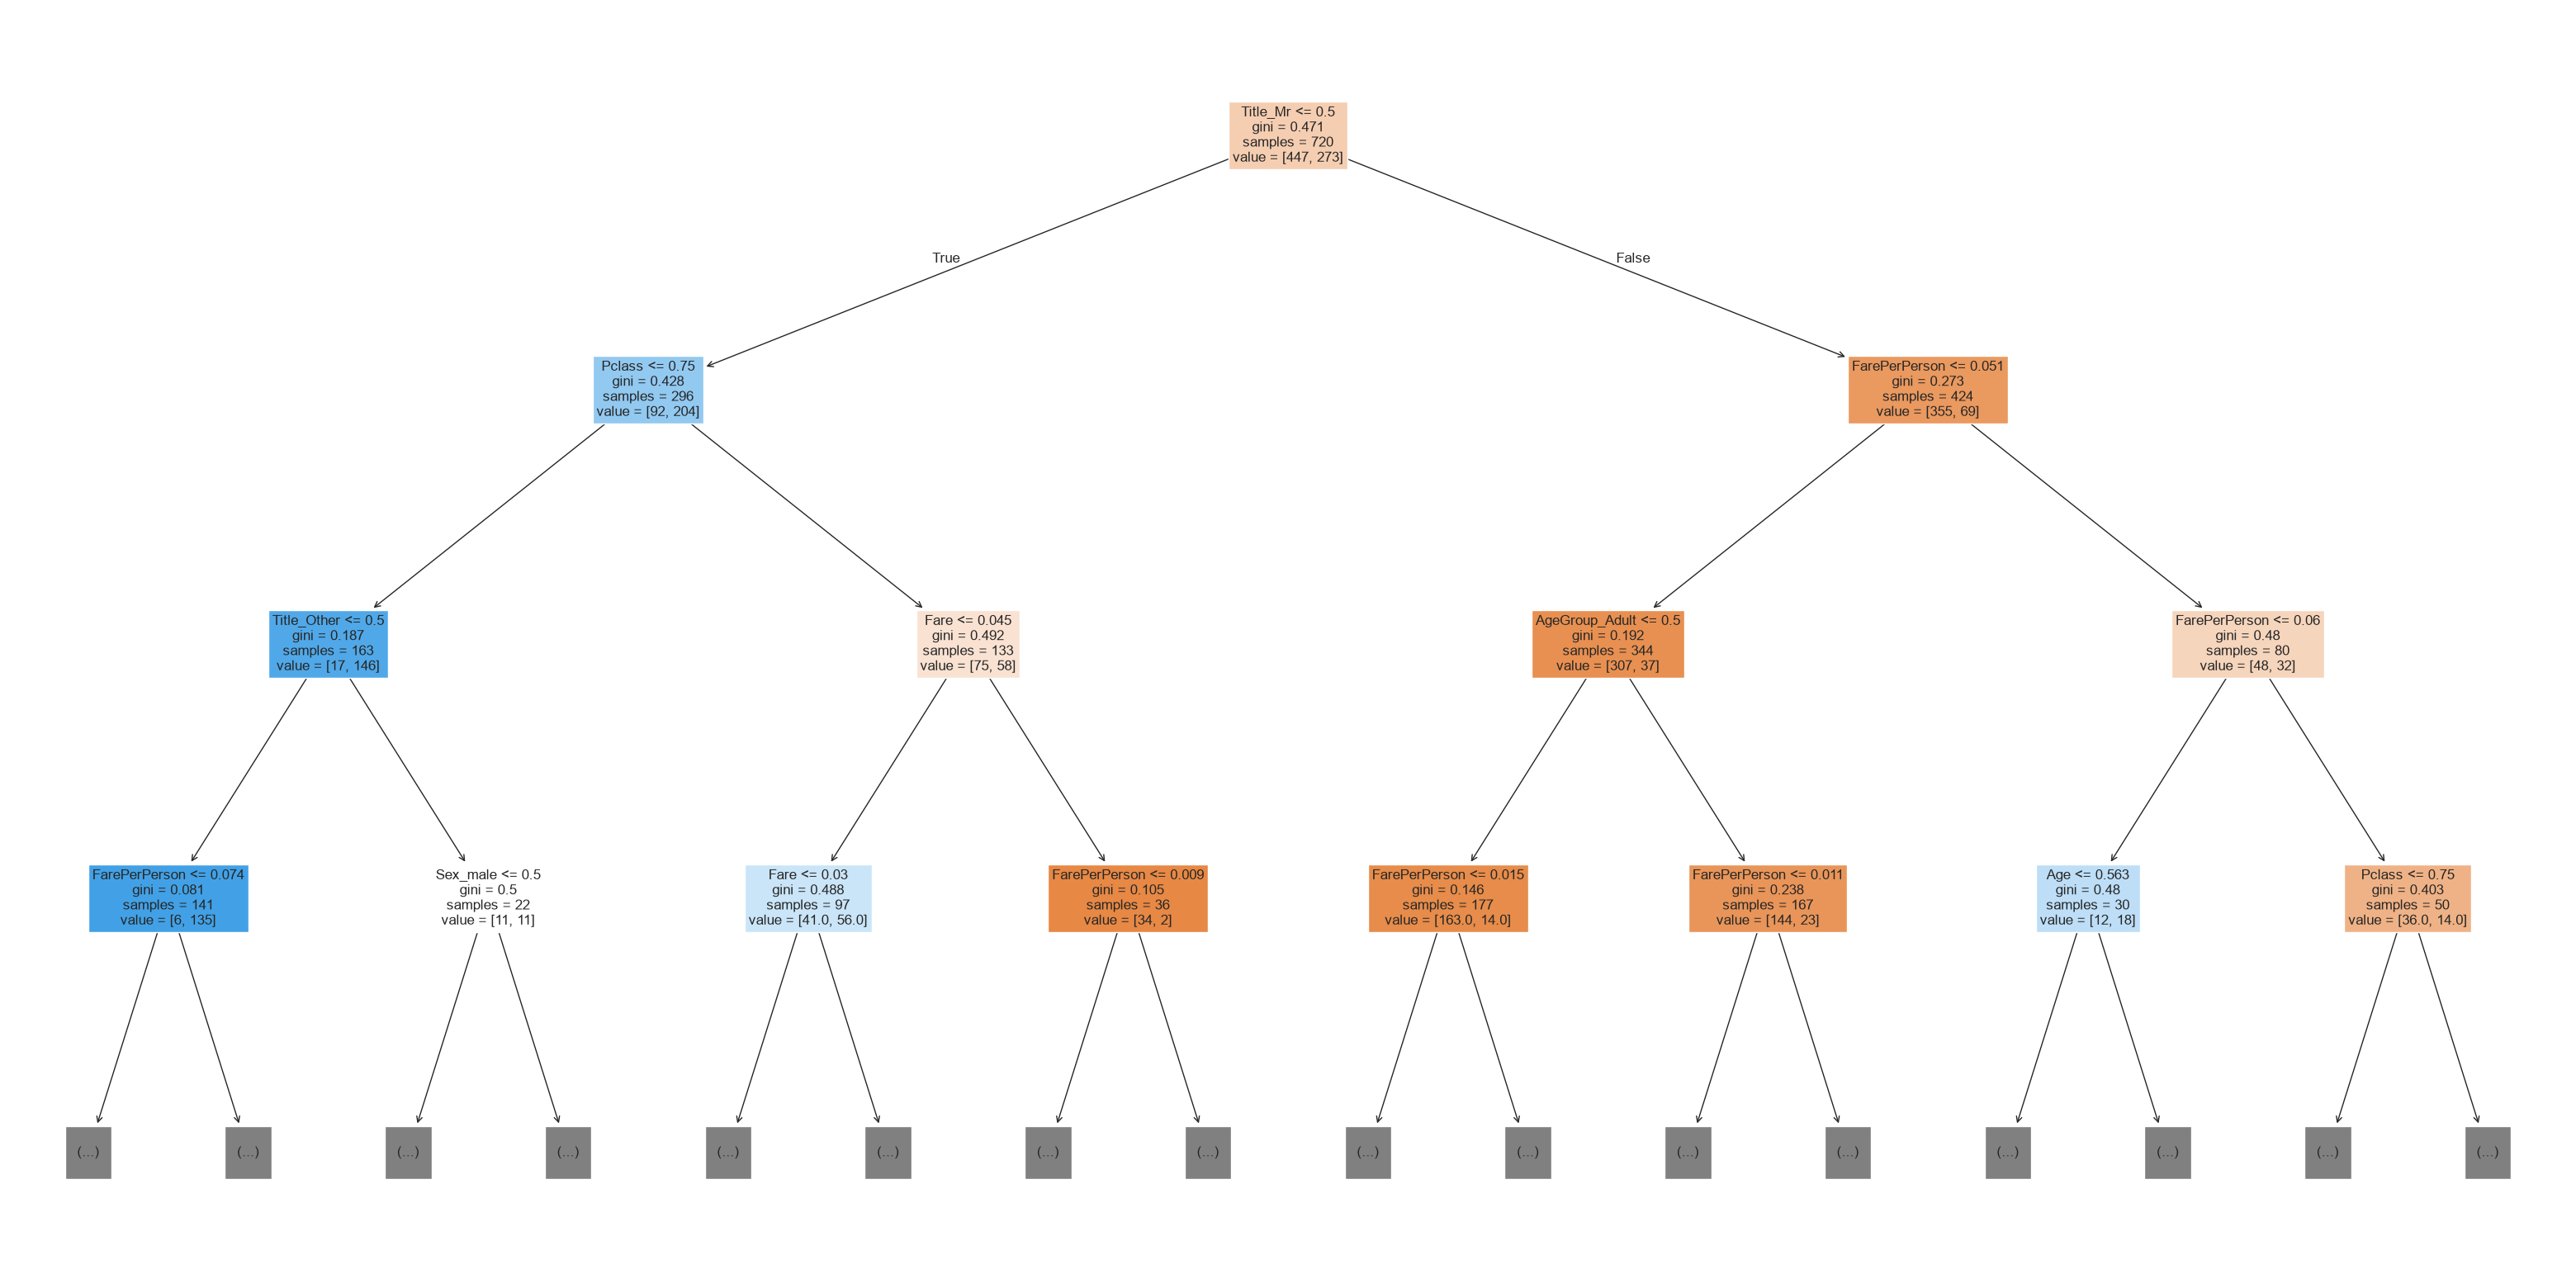

In [40]:
plt.figure(figsize = (40, 20))
plot_tree(tree, feature_names = X_train.columns, filled = True, max_depth = 3)

In [41]:
from sklearn.ensemble import RandomForestClassifier

In [42]:
rf = RandomForestClassifier(random_state = 42)
try_model(rf)

(0.9833333333333333, 0.8271604938271605)

In [43]:
rf.feature_importances_

array([5.81146484e-02, 1.41560432e-01, 3.07544600e-02, 1.73853340e-02,
       1.49941277e-01, 4.03250941e-02, 8.06619350e-03, 1.56676289e-01,
       6.05101300e-02, 9.45510824e-02, 1.39948009e-02, 5.82039279e-03,
       1.27302581e-02, 5.53685128e-03, 1.49461301e-02, 1.04535181e-01,
       2.33998957e-02, 5.67761147e-03, 1.31855055e-07, 1.67155980e-02,
       8.10564970e-03, 9.13184599e-03, 5.01733608e-03, 5.44048525e-03,
       1.10628919e-02])

In [44]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending = False)

In [45]:
importance_df

,feature,importance
7,FarePerPerson,1.566763e-01
4,Fare,1.499413e-01
1,Age,1.415604e-01
15,Title_Mr,1.045352e-01
9,Sex_male,9.455108e-02
8,Sex_female,6.051013e-02
0,Pclass,5.811465e-02
5,FamilySize,4.032509e-02
2,SibSp,3.075446e-02
16,Title_Mrs,2.339990e-02


<Axes: xlabel='importance', ylabel='feature'>

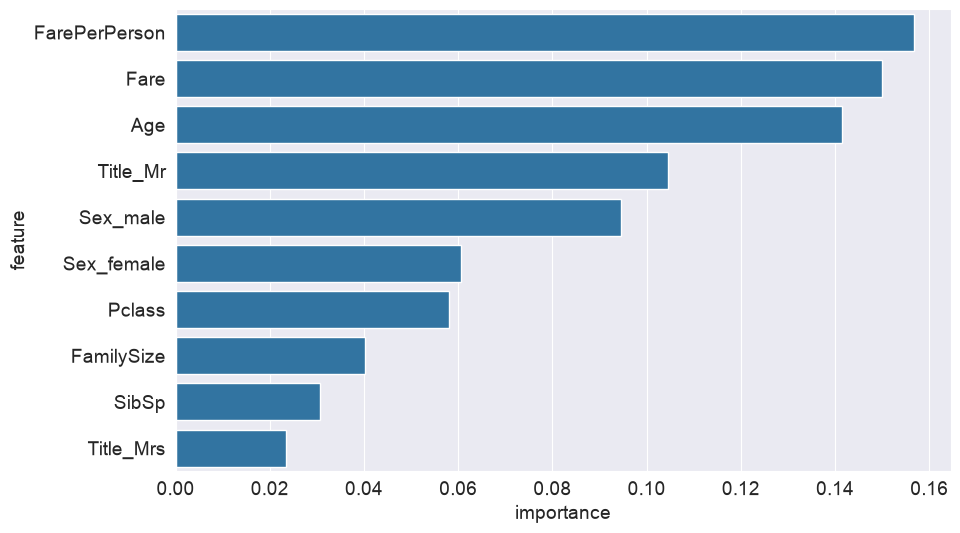

In [46]:
sns.barplot(importance_df.head(10), x = 'importance', y = 'feature')

In [47]:
test_preds = rf.predict(X_test)
test_preds

array([1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0])

In [48]:
accuracy_score(test_preds, test_targets)

0.8444444444444444

In [49]:
print("=" * 50)
print("TITANIC SURVIVAL PREDICTION — RESULTS")
print("=" * 50)
print(f"Baseline (majority class): ~{accuracy_score(val_targets, baseline_model(X_val))*100:.1f}%")
lr_train, lr_val = try_model(LogisticRegression(max_iter=1000))
dt_train, dt_val = try_model(DecisionTreeClassifier(random_state=42))
rf_train, rf_val = try_model(RandomForestClassifier(random_state=42, n_jobs=-1))
print(f"Logistic Regression Val:   {lr_val*100:.1f}%")
print(f"Decision Tree Val:         {dt_val*100:.1f}%")
print(f"Random Forest Val:         {rf_val*100:.1f}%")
print(f"Final Test Accuracy:       {accuracy_score(test_targets, test_preds)*100:.1f}%")
print("=" * 50)

TITANIC SURVIVAL PREDICTION — RESULTS
Baseline (majority class): ~59.3%
Logistic Regression Val:   86.4%
Decision Tree Val:         80.2%
Random Forest Val:         82.7%
Final Test Accuracy:       84.4%
